# Eigenspectra scheme

Simple stand-alone notebook that draws the eigenspectrum of the two-area connectivity matrix `W` for two chosen parameter sets, using the decomposition `W = S + R`:

- **red** = the two eigenvalues of the structural part `S` (the outliers)
- **blue** = the eigenvalues of the random part `R = W - S` (the bulk)
- **black dashed circle** = the theoretically predicted bulk radius $r_R=\sqrt{\rho(G)}$

Building blocks are reused from `Pertubation_case_study_energy.ipynb` (connectivity + `build_mean_connectivity_dense`) and `Draw_theory_prediction.ipynb` (theory).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle
from scipy.sparse import csr_matrix
from dataclasses import dataclass
from typing import Any, Dict, List, Mapping, Optional, Sequence, Tuple

In [2]:
# ============================================================
#  Parameters
# ============================================================

@dataclass(frozen=True)
class AreaParams:
    """
    Parameters for one brain area.

    N      : number of neurons in this area
    s      : local sparsity, defined by C_i / N_i
    f_exc  : fraction of excitatory neurons in this area
    J_exc  : local excitatory synaptic weight in this area
    g_inh  : local inhibitory strength ratio
    """
    N: int
    s: float
    f_exc: float
    J_exc: float
    g_inh: float


@dataclass(frozen=True)
class MultiAreaParams:
    """
    Parameters for the full multi-area network.

    s_cross[src, tgt] : cross-area sparsity from src to tgt
    J_cross[src, tgt] : cross-area excitatory weight from src to tgt

    activation: "tanh" or "threshold_linear"
    phi_max   : only used if activation == "threshold_linear"
    gamma     : threshold offset in phi(x) = max(0, x + gamma)
    """
    areas: Tuple[AreaParams, ...]
    s_cross: np.ndarray
    J_cross: np.ndarray
    allow_autapses: bool
    activation: str
    phi_max: float
    gamma: float
    dt: float
    T: float
    seed: int = 0


# ============================================================
#  Activation
# ============================================================

def phi(x: np.ndarray, p: MultiAreaParams) -> np.ndarray:
    x = np.asarray(x, dtype=float)

    if p.activation == "tanh":
        return np.tanh(x) + 1.0

    if p.activation == "threshold_linear":
        y = np.maximum(0.0, x + p.gamma)
        if np.isfinite(p.phi_max):
            y = np.minimum(p.phi_max, y)
        return y

    raise ValueError(f"Unknown activation = {p.activation}")


def phi_prime(x: np.ndarray, p: MultiAreaParams) -> np.ndarray:
    x = np.asarray(x, dtype=float)

    if p.activation == "tanh":
        y = np.tanh(x)
        return 1.0 - y * y

    if p.activation == "threshold_linear":
        g = ((x + p.gamma) >= 0.0).astype(float)
        if np.isfinite(p.phi_max):
            g = g * ((x + p.gamma) < p.phi_max)
        return g

    raise ValueError(f"Unknown activation = {p.activation}")


# ============================================================
#  Population bookkeeping
# ============================================================

def population_info(p: MultiAreaParams) -> Dict[str, Any]:
    pops = []
    pop_sizes = []
    pop_slices = {}
    area_slices = {}
    area_stats = []

    start = 0
    for area_id, ap in enumerate(p.areas):
        N_E = int(round(ap.f_exc * ap.N))
        N_I = ap.N - N_E

        if N_E < 0 or N_I < 0:
            raise ValueError(f"Area {area_id}: invalid E/I split")

        C = int(round(ap.s * ap.N))
        C_E = int(round(ap.f_exc * C))
        C_I = C - C_E

        e_slice = slice(start, start + N_E)
        pops.append((area_id, "E"))
        pop_slices[(area_id, "E")] = e_slice
        pop_sizes.append(N_E)
        start += N_E

        i_slice = slice(start, start + N_I)
        pops.append((area_id, "I"))
        pop_slices[(area_id, "I")] = i_slice
        pop_sizes.append(N_I)
        start += N_I

        area_slices[area_id] = slice(e_slice.start, i_slice.stop)

        area_stats.append(
            {
                "area_id": area_id,
                "N": ap.N,
                "N_E": N_E,
                "N_I": N_I,
                "C": C,
                "C_E": C_E,
                "C_I": C_I,
                "J_E": ap.J_exc,
                "J_I": -ap.g_inh * ap.J_exc,
            }
        )

    return {
        "pops": pops,
        "pop_sizes": np.asarray(pop_sizes, dtype=int),
        "N_total": start,
        "pop_slices": pop_slices,
        "area_slices": area_slices,
        "area_stats": area_stats,
    }


def _validate_params(p: MultiAreaParams) -> None:
    A = len(p.areas)

    if p.s_cross.shape != (A, A):
        raise ValueError(f"s_cross must have shape ({A}, {A})")
    if p.J_cross.shape != (A, A):
        raise ValueError(f"J_cross must have shape ({A}, {A})")

    for area_id, ap in enumerate(p.areas):
        if ap.N <= 0:
            raise ValueError(f"Area {area_id}: N must be positive")
        if not (0.0 <= ap.s <= 1.0):
            raise ValueError(f"Area {area_id}: s must be in [0, 1]")
        if not (0.0 <= ap.f_exc <= 1.0):
            raise ValueError(f"Area {area_id}: f_exc must be in [0, 1]")

    if np.any(p.s_cross < 0.0) or np.any(p.s_cross > 1.0):
        raise ValueError("All s_cross entries must be in [0, 1]")


def _candidate_pool(indices: np.ndarray, target_idx: int, allow_autapses: bool) -> np.ndarray:
    if allow_autapses or len(indices) == 0:
        return indices

    if indices[0] <= target_idx <= indices[-1]:
        return indices[indices != target_idx]
    return indices

In [3]:
# ============================================================
#  Connectivity
# ============================================================

def build_multi_area_connectivity(p: MultiAreaParams) -> Tuple[csr_matrix, Dict[str, Any]]:
    """
    Build the full sparse recurrent matrix W.
    Convention: W[i, j] = connection from neuron j to neuron i.
    """
    _validate_params(p)
    rng = np.random.default_rng(p.seed)
    info = population_info(p)

    A = len(p.areas)
    N_total = info["N_total"]
    pop_slices = info["pop_slices"]
    area_stats = info["area_stats"]

    rows: List[int] = []
    cols: List[int] = []
    data: List[float] = []

    for tgt_area in range(A):
        stat_t = area_stats[tgt_area]
        tgt_all = np.arange(info["area_slices"][tgt_area].start, info["area_slices"][tgt_area].stop)
        tgt_exc = np.arange(pop_slices[(tgt_area, "E")].start, pop_slices[(tgt_area, "E")].stop)
        tgt_inh = np.arange(pop_slices[(tgt_area, "I")].start, pop_slices[(tgt_area, "I")].stop)

        C_E_local = stat_t["C_E"]
        C_I_local = stat_t["C_I"]
        w_E_local = stat_t["J_E"]
        w_I_local = stat_t["J_I"]

        for i_tgt in tgt_all:
            exc_pool = _candidate_pool(tgt_exc, i_tgt, p.allow_autapses)
            inh_pool = _candidate_pool(tgt_inh, i_tgt, p.allow_autapses)

            if C_E_local > len(exc_pool):
                raise ValueError(
                    f"Area {tgt_area}: local C_E={C_E_local} exceeds available local excitatory pool={len(exc_pool)}"
                )
            if C_I_local > len(inh_pool):
                raise ValueError(
                    f"Area {tgt_area}: local C_I={C_I_local} exceeds available local inhibitory pool={len(inh_pool)}"
                )

            if C_E_local > 0:
                pre_exc = rng.choice(exc_pool, size=C_E_local, replace=False)
                rows.extend([i_tgt] * C_E_local)
                cols.extend(pre_exc.tolist())
                data.extend([w_E_local] * C_E_local)

            if C_I_local > 0:
                pre_inh = rng.choice(inh_pool, size=C_I_local, replace=False)
                rows.extend([i_tgt] * C_I_local)
                cols.extend(pre_inh.tolist())
                data.extend([w_I_local] * C_I_local)

            for src_area in range(A):
                if src_area == tgt_area:
                    continue

                src_exc = np.arange(pop_slices[(src_area, "E")].start, pop_slices[(src_area, "E")].stop)
                if len(src_exc) == 0:
                    continue

                s_ij = float(p.s_cross[src_area, tgt_area])
                if s_ij <= 0.0:
                    continue

                C_cross = int(round(s_ij * len(src_exc)))
                if C_cross == 0:
                    continue
                if C_cross > len(src_exc):
                    raise ValueError(
                        f"Cross ({src_area}->{tgt_area}): C_cross={C_cross} exceeds source excitatory pool={len(src_exc)}"
                    )

                pre_cross = rng.choice(src_exc, size=C_cross, replace=False)
                w_cross = float(p.J_cross[src_area, tgt_area])

                rows.extend([i_tgt] * C_cross)
                cols.extend(pre_cross.tolist())
                data.extend([w_cross] * C_cross)

    W = csr_matrix(
        (
            np.asarray(data, dtype=float),
            (np.asarray(rows, dtype=int), np.asarray(cols, dtype=int)),
        ),
        shape=(N_total, N_total),
    )

    meta = {
        "N_total": N_total,
        "pops": info["pops"],
        "pop_sizes": info["pop_sizes"],
        "pop_slices": pop_slices,
        "area_slices": info["area_slices"],
        "area_stats": area_stats,
        "nnz": W.nnz,
    }
    return W, meta


def lift_population_values_to_neurons(values: np.ndarray, p: MultiAreaParams) -> np.ndarray:
    info = population_info(p)
    pops = info["pops"]
    pop_slices = info["pop_slices"]
    N_total = info["N_total"]

    out = np.empty(N_total, dtype=float)
    for k, (area_id, cell_type) in enumerate(pops):
        out[pop_slices[(area_id, cell_type)]] = values[k]
    return out

In [4]:
# ============================================================
#  Structural mean connectivity  S = E[W]  (dense)
# ============================================================

def build_mean_connectivity_dense(p: MultiAreaParams) -> np.ndarray:
    """
    Build the mean connectivity matrix S = E[W] numerically
    from the same block means used in your note.

    Convention:
      W[i, j] = connection from neuron j to neuron i

    We use the same simplified mean structure as in the note:
    - within one area:
        source E projects with mean  J_exc * C_E / N_E
        source I projects with mean -g*J_exc * C_I / N_I
      onto both E and I targets in the same area
    - across areas:
        only source E projects, with mean J_cross * C_cross / N_E(src)
      onto all neurons in the target area
    """
    info = population_info(p)
    pop_slices = info["pop_slices"]
    area_slices = info["area_slices"]
    area_stats = info["area_stats"]
    N_total = info["N_total"]
    A = len(p.areas)

    S = np.zeros((N_total, N_total), dtype=float)

    for tgt in range(A):
        tgt_all = area_slices[tgt]

        for src in range(A):
            src_E = pop_slices[(src, "E")]
            src_I = pop_slices[(src, "I")]
            stat_s = area_stats[src]

            N_E_src = stat_s["N_E"]
            N_I_src = stat_s["N_I"]

            if src == tgt:
                # local E source mean
                mu_E = 0.0 if N_E_src == 0 else stat_s["J_E"] * stat_s["C_E"] / N_E_src
                # local I source mean
                mu_I = 0.0 if N_I_src == 0 else stat_s["J_I"] * stat_s["C_I"] / N_I_src

                S[tgt_all, src_E] = mu_E
                S[tgt_all, src_I] = mu_I

            else:
                # cross-area: only source E projects
                q = float(p.s_cross[src, tgt])
                C_cross = int(round(q * N_E_src))
                mu_cross = 0.0 if N_E_src == 0 else float(p.J_cross[src, tgt]) * C_cross / N_E_src

                S[tgt_all, src_E] = mu_cross
                S[tgt_all, src_I] = 0.0

    return S

In [5]:
# ============================================================
#  Theory: bulk radius  r_R = sqrt(rho(G))  and the two
#  structural roots (the outliers)
# ============================================================

def _candidate_pool_size(
    pop_size: int,
    target_belongs_to_source_pool: bool,
    allow_autapses: bool
) -> int:
    """
    Exact source pool size under your construction rule.
    """
    if allow_autapses:
        return pop_size
    return pop_size - 1 if target_belongs_to_source_pool else pop_size


def _variance_fixed_indegree_entry(weight: float, indegree: int, pool_size: int) -> float:
    """
    Exact single-entry variance for fixed in-degree sampling without replacement:
        P(conn) = indegree / pool_size
        Var(W_ij) = weight^2 * p * (1-p)
    """
    if pool_size <= 0:
        return np.nan
    if indegree < 0 or indegree > pool_size:
        return np.nan

    p_conn = indegree / pool_size
    return (weight ** 2) * p_conn * (1.0 - p_conn)


def build_random_variance_matrix_full_4x4(p: MultiAreaParams) -> np.ndarray:
    """
    Full 4x4 block variance matrix G for the two-area case.

    Population order:
        0: area0,E
        1: area0,I
        2: area1,E
        3: area1,I

    G_cd = alpha_c * g_cd^2 = n_c * Var(block_cd entry)
    """
    _validate_params(p)

    if len(p.areas) != 2:
        raise ValueError("Current implementation assumes exactly 2 areas.")

    info = population_info(p)
    st0, st1 = info["area_stats"]
    ap0, ap1 = p.areas

    N_E0, N_I0 = st0["N_E"], st0["N_I"]
    N_E1, N_I1 = st1["N_E"], st1["N_I"]

    C_E0, C_I0 = st0["C_E"], st0["C_I"]
    C_E1, C_I1 = st1["C_E"], st1["C_I"]

    C_0_to_1 = int(round(float(p.s_cross[0, 1]) * N_E0))
    C_1_to_0 = int(round(float(p.s_cross[1, 0]) * N_E1))

    J0 = ap0.J_exc
    J1 = ap1.J_exc
    JI0 = -ap0.g_inh * ap0.J_exc
    JI1 = -ap1.g_inh * ap1.J_exc
    J_0_to_1 = float(p.J_cross[0, 1])
    J_1_to_0 = float(p.J_cross[1, 0])

    row_sizes = np.array([N_E0, N_I0, N_E1, N_I1], dtype=float)
    G = np.zeros((4, 4), dtype=float)

    # row 0: target area0, E
    G[0, 0] = row_sizes[0] * _variance_fixed_indegree_entry(
        J0, C_E0,
        _candidate_pool_size(N_E0, True, p.allow_autapses)
    )
    G[0, 1] = row_sizes[0] * _variance_fixed_indegree_entry(
        JI0, C_I0,
        _candidate_pool_size(N_I0, False, p.allow_autapses)
    )
    G[0, 2] = row_sizes[0] * _variance_fixed_indegree_entry(
        J_1_to_0, C_1_to_0, N_E1
    )
    G[0, 3] = 0.0

    # row 1: target area0, I
    G[1, 0] = row_sizes[1] * _variance_fixed_indegree_entry(
        J0, C_E0,
        _candidate_pool_size(N_E0, False, p.allow_autapses)
    )
    G[1, 1] = row_sizes[1] * _variance_fixed_indegree_entry(
        JI0, C_I0,
        _candidate_pool_size(N_I0, True, p.allow_autapses)
    )
    G[1, 2] = row_sizes[1] * _variance_fixed_indegree_entry(
        J_1_to_0, C_1_to_0, N_E1
    )
    G[1, 3] = 0.0

    # row 2: target area1, E
    G[2, 0] = row_sizes[2] * _variance_fixed_indegree_entry(
        J_0_to_1, C_0_to_1, N_E0
    )
    G[2, 1] = 0.0
    G[2, 2] = row_sizes[2] * _variance_fixed_indegree_entry(
        J1, C_E1,
        _candidate_pool_size(N_E1, True, p.allow_autapses)
    )
    G[2, 3] = row_sizes[2] * _variance_fixed_indegree_entry(
        JI1, C_I1,
        _candidate_pool_size(N_I1, False, p.allow_autapses)
    )

    # row 3: target area1, I
    G[3, 0] = row_sizes[3] * _variance_fixed_indegree_entry(
        J_0_to_1, C_0_to_1, N_E0
    )
    G[3, 1] = 0.0
    G[3, 2] = row_sizes[3] * _variance_fixed_indegree_entry(
        J1, C_E1,
        _candidate_pool_size(N_E1, False, p.allow_autapses)
    )
    G[3, 3] = row_sizes[3] * _variance_fixed_indegree_entry(
        JI1, C_I1,
        _candidate_pool_size(N_I1, True, p.allow_autapses)
    )

    return G


def theoretical_random_radius(p: MultiAreaParams) -> float:
    """
    Bulk radius of random part:
        r_R = sqrt( rho(G) )
    """
    G = build_random_variance_matrix_full_4x4(p)

    if not np.all(np.isfinite(G)):
        return np.nan

    eigvals = np.linalg.eigvals(G)
    rho = float(np.max(eigvals.real))

    if rho < 0.0 and abs(rho) < 1e-12:
        rho = 0.0
    if rho < 0.0:
        return np.nan

    return float(np.sqrt(rho))


def build_structured_matrix_2x2(p: MultiAreaParams) -> np.ndarray:
    """
    Reduced 2x2 structured matrix:

        [ Lambda_0      Gamma_{1->0} ]
        [ Gamma_{0->1}  Lambda_1     ]

    where
        Lambda_i = J_i * (C_Ei - g_i C_Ii)
        Gamma_{src->tgt} = J_cross[src,tgt] * C_{src->tgt}
    """
    _validate_params(p)

    if len(p.areas) != 2:
        raise ValueError("Current implementation assumes exactly 2 areas.")

    info = population_info(p)
    st0, st1 = info["area_stats"]
    ap0, ap1 = p.areas

    C_0_to_1 = int(round(float(p.s_cross[0, 1]) * st0["N_E"]))
    C_1_to_0 = int(round(float(p.s_cross[1, 0]) * st1["N_E"]))

    Lambda_0 = ap0.J_exc * (st0["C_E"] - ap0.g_inh * st0["C_I"])
    Lambda_1 = ap1.J_exc * (st1["C_E"] - ap1.g_inh * st1["C_I"])

    Gamma_0_to_1 = float(p.J_cross[0, 1]) * C_0_to_1
    Gamma_1_to_0 = float(p.J_cross[1, 0]) * C_1_to_0

    return np.array([
        [Lambda_0,     Gamma_1_to_0],
        [Gamma_0_to_1, Lambda_1    ],
    ], dtype=float)


def theoretical_structured_roots(p: MultiAreaParams) -> Tuple[float, float]:
    """
    Return the two nonzero real eigenvalues of S:
        lambda_plus >= lambda_minus
    """
    M = build_structured_matrix_2x2(p)
    eigvals = np.linalg.eigvals(M)

    if np.max(np.abs(eigvals.imag)) > 1e-10:
        return np.nan, np.nan

    vals = np.sort(eigvals.real)[::-1]
    return float(vals[0]), float(vals[1])

In [6]:
# ============================================================
#  Eigenspectrum scheme for one parameter set:
#    blue  = eigenvalues of the random part  R = W - S   (bulk disk)
#    red   = the two eigenvalues of the structural part  S  (outliers)
#    black dashed circle = theoretical bulk radius  sqrt(rho(G))
#  No other lines are drawn.
# ============================================================

def plot_eigenspectrum_scheme(ax, p: MultiAreaParams, title: str):
    # build connectivity and decompose  W = S + R
    W, _ = build_multi_area_connectivity(p)
    W_dense = W.toarray()
    S_dense = build_mean_connectivity_dense(p)

    eig_R = np.linalg.eigvals(W_dense - S_dense)   # random bulk
    eig_S = np.linalg.eigvals(S_dense)             # structural part

    # S has rank 2, so its two nonzero eigenvalues (largest |.|) are the outliers
    idx = np.argsort(np.abs(eig_S))[::-1][:2]
    outliers = eig_S[idx]

    # theoretical bulk radius
    R_theory = theoretical_random_radius(p)

    # --- draw: bulk (blue), outliers (red), theory circle (black dashed) ---
    ax.scatter(eig_R.real, eig_R.imag, s=5, color="tab:blue", alpha=0.5,
               edgecolors="none")
    ax.scatter(outliers.real, outliers.imag, s=70, color="red",
               marker="o", zorder=5)
    ax.add_patch(Circle((0.0, 0.0), R_theory, fill=False, linestyle="--",
                        edgecolor="k", linewidth=1.5))

    # square frame containing everything, equal aspect so the circle is round
    lim = 1.15 * max(float(np.max(np.abs(eig_R))),
                     float(np.max(np.abs(outliers))),
                     float(R_theory))
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal", "box")
    ax.set_xlabel(r"$\mathrm{Re}(\lambda)$")
    ax.set_ylabel(r"$\mathrm{Im}(\lambda)$")
    ax.set_title(title, fontsize=11)

    handles = [
        Line2D([0], [0], marker="o", linestyle="none", markerfacecolor="red",
               markeredgecolor="red", markersize=9, label="Structural outliers"),
        Line2D([0], [0], marker="o", linestyle="none", markerfacecolor="tab:blue",
               markeredgecolor="none", markersize=7, label="Random bulk"),
        Line2D([0], [0], color="k", linestyle="--", linewidth=1.5,
               label="Theoretical radius"),
    ]
    ax.legend(handles=handles, loc="upper left", frameon=True, fontsize=9)

    return {"eig_R": eig_R, "outliers": outliers, "R_theory": R_theory}

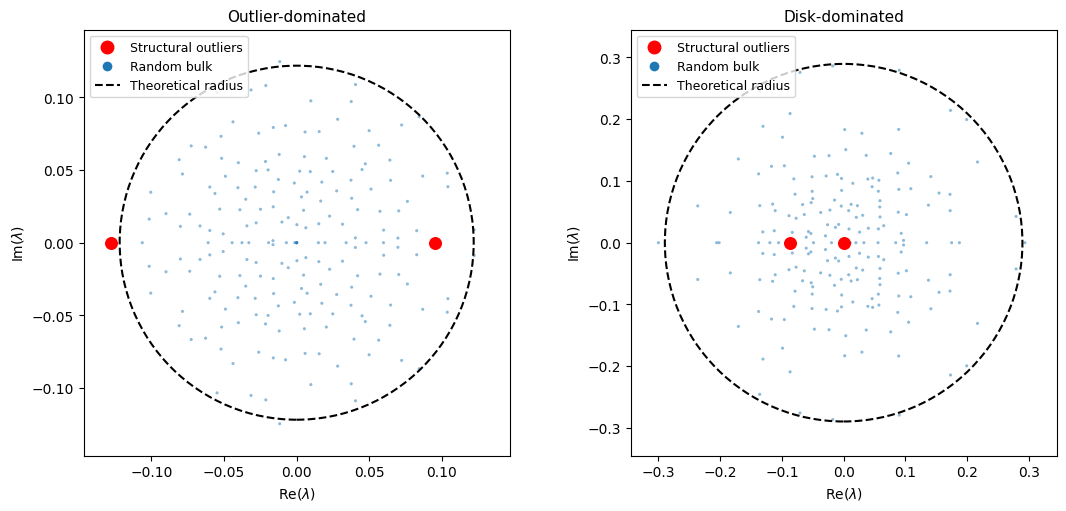

In [7]:
# ============================================================
#  Two parameter sets (matched "_010" pair, leading eigenvalue ~ 0.9)
#  from Pertubation-2area-multi-run_energy.ipynb:
#    - outlier-dominated : outlier lambda_+ ~ 0.90, bulk radius ~ 0.39
#    - disk-dominated    : bulk radius ~ 0.88, structural roots inside the disk
# ============================================================

N          = 100
s_local    = 0.1
f_exc      = 0.8
g_inh      = 4.5
s_cross_ij = 0.05

def make_p(J_exc: float, J_cross: float, seed: int = 0) -> MultiAreaParams:
    area = AreaParams(N=N, s=s_local, f_exc=f_exc, J_exc=J_exc, g_inh=g_inh)
    s_cross_mat = np.zeros((2, 2), dtype=float)
    J_cross_mat = np.zeros((2, 2), dtype=float)
    s_cross_mat[0, 1] = s_cross_mat[1, 0] = s_cross_ij
    J_cross_mat[0, 1] = J_cross_mat[1, 0] = J_cross
    return MultiAreaParams(
        areas=(area, area),
        s_cross=s_cross_mat,
        J_cross=J_cross_mat,
        allow_autapses=False,
        activation="threshold_linear",
        phi_max=np.inf,
        gamma=0.5,
        dt=0.005,
        T=60.0,
        seed=seed,
    )

p_outlier = make_p(J_exc=0.0163, J_cross=0.0278)   # outlier-dominated
p_disk    = make_p(J_exc=0.0430, J_cross=0.0108)   # disk-dominated

fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
plot_eigenspectrum_scheme(axes[0], p_outlier, "Outlier-dominated")
plot_eigenspectrum_scheme(axes[1], p_disk,    "Disk-dominated")
#fig.savefig("eigenspectra_scheme.png", dpi=300, bbox_inches="tight")
plt.show()

## Exact connectivity matrix visualization

The panels below show the realized sparse matrix `W`: red entries are positive, blue entries are negative, and white entries are zero.

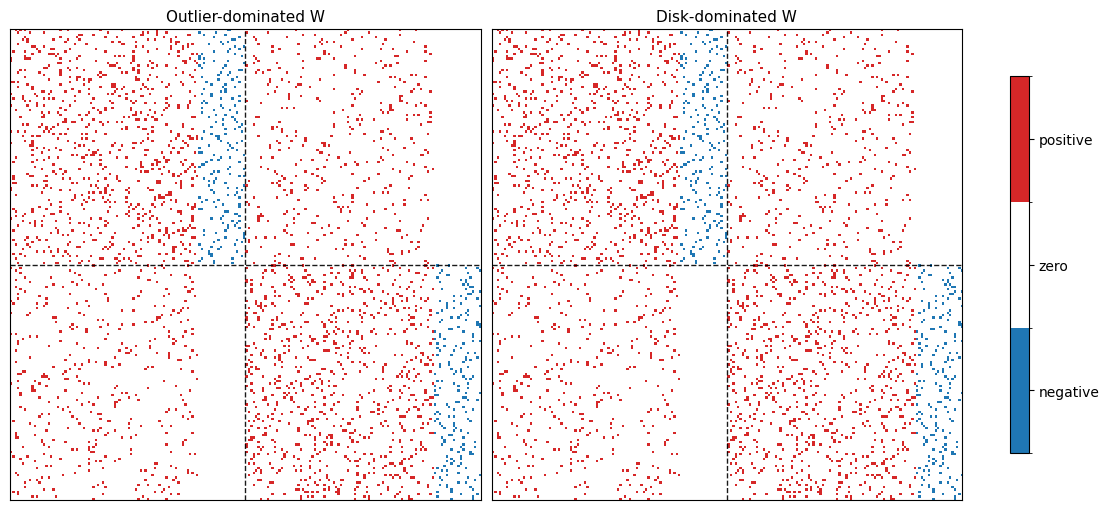

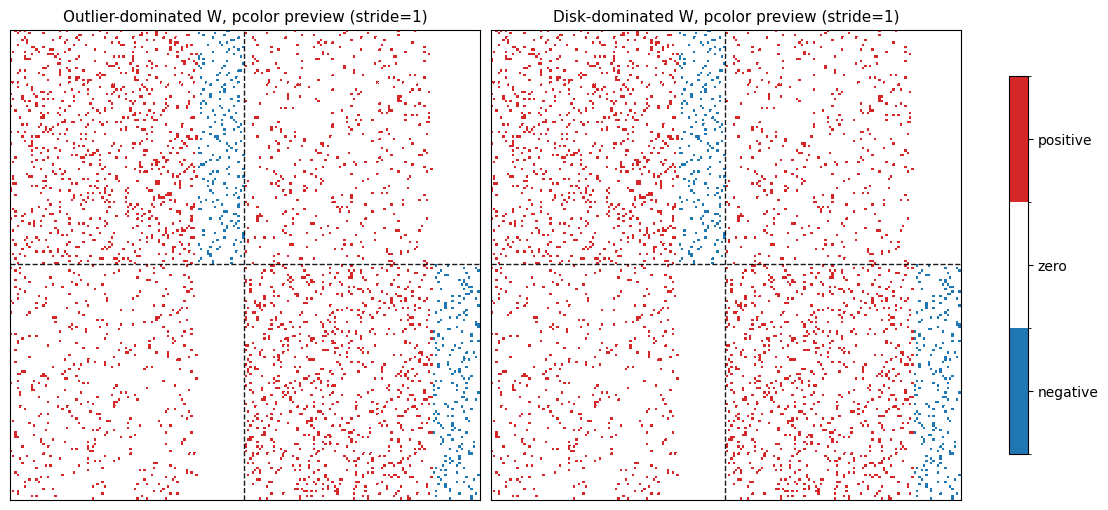

In [8]:
# ============================================================
#  Exact matrix visualization:
#    red   = positive entries
#    blue  = negative entries
#    white = zero entries
# ============================================================

from matplotlib.colors import BoundaryNorm, ListedColormap

signed_cmap = ListedColormap(["tab:blue", "white", "tab:red"])
signed_norm = BoundaryNorm([-1.5, -0.5, 0.5, 1.5], signed_cmap.N)


def signed_dense_from_sparse(W: csr_matrix) -> np.ndarray:
    signed = np.zeros(W.shape, dtype=np.int8)
    W_coo = W.tocoo()
    signed[W_coo.row, W_coo.col] = np.sign(W_coo.data).astype(np.int8)
    return signed


def add_population_boundaries(ax, meta: Dict[str, Any], scale: float = 1.0) -> None:
    area_edges = np.array(
        [meta["area_slices"][area_id].stop for area_id in sorted(meta["area_slices"])][:-1],
        dtype=float,
    ) / scale

    for edge in area_edges:
        ax.axhline(edge - 0.5, color="black", linestyle="--", linewidth=1.0, alpha=0.9)
        ax.axvline(edge - 0.5, color="black", linestyle="--", linewidth=1.0, alpha=0.9)


def hide_matrix_axis_indices(ax) -> None:
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])


def plot_signed_matrix_imshow(ax, p: MultiAreaParams, title: str):
    W, meta = build_multi_area_connectivity(p)
    signed = signed_dense_from_sparse(W)

    image = ax.imshow(signed, cmap=signed_cmap, norm=signed_norm,
                      interpolation="none", origin="upper", aspect="equal")
    add_population_boundaries(ax, meta)
    ax.set_title(title, fontsize=11)
    hide_matrix_axis_indices(ax)
    return image, signed, meta


fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
matrix_cache = []
for ax, p, title in [
    (axes[0], p_outlier, "Outlier-dominated W"),
    (axes[1], p_disk, "Disk-dominated W"),
]:
    image, signed, meta = plot_signed_matrix_imshow(ax, p, title)
    matrix_cache.append((signed, meta))

cbar = fig.colorbar(image, ax=axes, ticks=[-1, 0, 1], shrink=0.8)
cbar.ax.set_yticklabels(["negative", "zero", "positive"])
fig.savefig("Matrix_scheme.png", dpi=300, bbox_inches="tight")
plt.show()


# pcolor is much slower on the full 4000 x 4000 matrix, so this draws a strided preview.
pcolor_max_size = 600
fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
for ax, (signed, meta), title in [
    (axes[0], matrix_cache[0], "Outlier-dominated W, pcolor preview"),
    (axes[1], matrix_cache[1], "Disk-dominated W, pcolor preview"),
]:
    stride = max(1, int(np.ceil(signed.shape[0] / pcolor_max_size)))
    preview = signed[::stride, ::stride]
    mesh = ax.pcolor(preview, cmap=signed_cmap, norm=signed_norm, edgecolors="none")
    add_population_boundaries(ax, meta, scale=stride)
    ax.invert_yaxis()
    ax.set_aspect("equal", "box")
    ax.set_title(f"{title} (stride={stride})", fontsize=11)
    hide_matrix_axis_indices(ax)

cbar = fig.colorbar(mesh, ax=axes, ticks=[-1, 0, 1], shrink=0.8)
cbar.ax.set_yticklabels(["negative", "zero", "positive"])
plt.show()